# 第17课 · 找到矩阵的"天然坐标系"——特征分解（eigendecomposition）A=PDP⁻¹，让矩阵乘法退化成数乘

**学习目标**
1. 会写特征方程（characteristic equation） `det(A − λI) = 0`，手算 2×2 特征值
2. 理解对角化 `A = P D P⁻¹`：换到特征基后，乘法变成数乘
3. 会用 `Aⁿ = P Dⁿ P⁻¹` 算矩阵幂的思路
4. 知道**并非总能对角化**：缺少 n 个独立特征向量时，装不齐 P（本课会点到边界）

> L14 已见过 `Av=λv`——本节把「一个方向」**打包成整矩阵分解**；对称矩阵是最常能对角化的友好情况。

**为什么对 Aurora 重要**：递归滤波器（recursive filter）和状态空间模型（state space model）的稳定性由系统矩阵的特征值（eigenvalue）决定——所有 `|λ| < 1` 则滤波器收敛；`aurora.audio.transforms` 的极点分析依赖这套分解。

← **上一课**　[L16 · 行列式与逆矩阵](L16_determinant_inverse.ipynb)

> 上节课学习了 **行列式与逆矩阵**：det(A) 的几何含义（面积缩放），求逆与何时不可逆。  
> 本课将探讨 **特征分解 A=PDP⁻¹**。

## 本课剧情：换个坐标系，乘法变成普通数乘

你有没有想过：为什么某些计算在特定坐标系下特别简单？

普通矩阵乘法 `A @ v` 很难——每次都要做 n² 次乘加。但如果 `v` 是特征向量，乘法退化成**标量乘法**：`A @ v = λ · v`，只需乘一个数。

特征分解（eigendecomposition）就是找到一组"天然坐标系"，让矩阵在这个基底下变成对角矩阵（diagonal matrix）D：

```
A = P D P⁻¹
```

含义：
- **P**：换到特征向量坐标系
- **D**：在新坐标系下，A 的作用只是各方向独立缩放（对角元素 = 特征值）
- **P⁻¹**：换回原始坐标系

这个分解有什么用？
- **矩阵幂次**：`Aⁿ = P Dⁿ P⁻¹`，Dⁿ 只需对角线各元素自乘 n 次
- **稳定性分析**：如果所有 |λᵢ| < 1，则 Aⁿ → 0（系统收敛）
- **PCA**：找协方差矩阵的特征向量 = 数据变化最大的方向

本课实现 `char_poly(A, λ) = det(A - λI)`，验证真正的特征值使其为零。

## 追问一步：为什么"一个特征向量"能撑起"一整套新坐标系"？

`Av = λv` 只描述了**一个**向量 v 的命运——它被 A 拉伸/翻转了 λ 倍。但上面说"整个矩阵 A 都能写成 P D P⁻¹"，这是从一个向量的关系跳到了整个矩阵的分解，中间少了一步。我们把这一步补上。

**生活类比**：搬家的时候，如果衣柜正好能沿着墙的方向推进房间（不用拐弯），这个方向对衣柜来说就是"顺畅方向"。但一个房间里往往有好几件家具，每件家具可能都有自己的顺畅方向（书架沿另一面墙、床沿第三个方向）。如果把这些顺畅方向**当成新的坐标轴**（书架方向当 x 轴、床方向当 y 轴……），那么在这套新坐标系里描述"搬家具"这件事，每个方向就都变得独立、互不干扰。特征分解做的正是这件事：把矩阵"喜欢"的那些方向找出来，当成新坐标轴。

**从一个关系到一整个矩阵方程**：假设我们已经找到了 n 个特征向量 v₁, v₂, …, vₙ（对应特征值 λ₁, λ₂, …, λₙ），把它们按列拼成一个矩阵：

```
P = [ v₁ | v₂ | ... | vₙ ]
```

现在把 A 乘到 P 上。矩阵乘以一组列向量，等价于把 A 分别乘到每一列上（这是 L12 学过的矩阵乘法规则）：

```
A P = A [v₁|v₂|...|vₙ] = [Av₁ | Av₂ | ... | Avₙ] = [λ₁v₁ | λ₂v₂ | ... | λₙvₙ]
```

而 `[λ₁v₁ | λ₂v₂ | ... | λₙvₙ]` 正好等于 `P` 乘以一个对角矩阵 `D = diag(λ₁,...,λₙ)`——因为"矩阵乘对角矩阵"就是把每一列分别乘上对角线上对应的数（L13 学过的规则）。所以：

```
A P = P D
```

如果 P 可逆（也就是这 n 个特征向量彼此线性独立，凑得齐一整套坐标轴——下面"常见误解"会讲什么时候凑不齐），两边同时右乘 P⁻¹：

```
A = P D P⁻¹
```

推导完毕：不是魔法，只是把 n 个"一个向量被独立缩放"的关系，用矩阵乘法的规则**打包成一个矩阵方程**，再解出 A。下面用代码亲眼验证 `AP` 和 `PD` 这一步中间等式确实成立。


In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
# 逐步验证推导的关键桥梁：AP = PD（这一步比最终的 A=PDP⁻¹ 更基础）
import numpy as np

A = np.array([[4., 1.], [2., 3.]])
lam, P = np.linalg.eig(A)          # P 的每一列就是一个特征向量
D = np.diag(lam)

AP = A @ P                          # 左边：A 分别作用在两个特征向量上
PD = P @ D                          # 右边：P 的每一列按对应特征值缩放

print('A @ P =\n', np.round(AP, 4))
print('P @ D =\n', np.round(PD, 4))
print('两者相等吗？', np.allclose(AP, PD))


A @ P =
 [[ 3.5355+0.j -0.8944+0.j]
 [ 3.5355+0.j  1.7889+0.j]]
P @ D =
 [[ 3.5355+0.j -0.8944+0.j]
 [ 3.5355+0.j  1.7889+0.j]]
两者相等吗？ True


## 1. 特征方程：`det(A − λI) = 0`

**如何找特征值？**

`Av = λv` 等价于 `(A - λI)v = 0`，有非零解 v 当且仅当 `A - λI` 奇异：

$$\det(A - \lambda I) = 0$$

这个方程的根就是特征值。

**2×2 手算例子**：A = [[4, 1], [2, 3]]

```
det(A - λI) = (4-λ)(3-λ) - 2·1
            = λ² - 7λ + 12 - 2
            = λ² - 7λ + 10
            = (λ-5)(λ-2) = 0
```

特征值：λ₁ = 5，λ₂ = 2。

**Python 验证**：`np.linalg.eig(A)` 直接返回特征值，`char_poly(A, 5)` 应约等于 0。

> n×n 矩阵有 n 个特征值（含重复和复数）；实对称矩阵的特征值全为实数。

### 追问：为什么"有非零解"就意味着"行列式为 0"？

这是这门课最容易卡住的一步，我们把它拆开揉碎讲。

**类比**：把矩阵 M 想成一台"绞肉机"：你从一端塞入一个向量 x，另一端吐出 Mx。正常情况下，不同的输入会绞出不同的输出——机器是"可逆"的，理论上能从绞出来的结果反推回原料（这就是逆矩阵 M⁻¹ 在做的事）。

但如果这台绞肉机有个"设计缺陷"：塞进某个**不是全零**的原料 v，吐出来的却是**空的**（零向量），那就说明这台机器把某些不同的输入压扁到了同一个输出上——它已经丢失了信息，没法逆着推回去了。这时候我们说 M **奇异（singular）**，也就是不可逆。

**这跟行列式有什么关系？** 行列式（L16 学过）衡量的是矩阵把空间"体积"缩放了多少倍。如果矩阵是奇异的——把某个非零向量压成了 0——那它相当于把整个空间压扁了至少一个维度（比如把一个立方体压成一张纸，甚至压成一条线）。被压扁后的体积是 0，所以行列式也是 0。反过来，如果 det(M) ≠ 0，说明体积没有被压扁到 0，矩阵仍然保留了全部维度的信息，是可逆的，那 Mx=0 就只有 x=0 这一个解（零向量绞出零向量，不算信息丢失）。

三件事其实是同一件事的三种说法：
1. `(A-λI)v = 0` 有非零解 v
2. `A-λI` 是奇异矩阵（不可逆）
3. `det(A-λI) = 0`

所以，"找到真正让 Av=λv 成立的 λ"，就等价于"找到让 A-λI 变成绞肉机（奇异）的 λ"，也就是解 `det(A-λI)=0`。下面代码把这三件事在具体数字上验证一遍：真特征值处 rank 会下降、det 会变 0；随便代入一个不是特征值的数，两者都不会出现。


In [3]:
# 亲眼验证：真特征值处矩阵"奇异"（rank 下降、det=0）；非特征值处不会
import numpy as np

A = np.array([[4., 1.], [2., 3.]])

for lam in (5, 2, 3):   # 5, 2 是真特征值；3 只是随便找的一个数，用来对照
    M = A - lam * np.eye(2)
    rank = np.linalg.matrix_rank(M)
    det = np.linalg.det(M)
    tag = '✅ 真特征值（奇异，rank 下降）' if abs(det) < 1e-8 else '❌ 不是特征值（可逆，rank 满）'
    print(f'λ={lam}:  rank(A-λI)={rank}  det(A-λI)={det:+.4f}  {tag}')


λ=5:  rank(A-λI)=1  det(A-λI)=+0.0000  ✅ 真特征值（奇异，rank 下降）
λ=2:  rank(A-λI)=1  det(A-λI)=+0.0000  ✅ 真特征值（奇异，rank 下降）
λ=3:  rank(A-λI)=2  det(A-λI)=-2.0000  ❌ 不是特征值（可逆，rank 满）


## ⚠️ 常见误解 (Common Pitfall)

> 不要以为"每个方阵都能干净地拆成 `P D P⁻¹`"。它其实**带前提**，下面三点是初学者最常栽的坑：

- **特征向量不唯一**：`v` 是特征向量，那 `2v`、`-v` 也都是——**方向**才是本质，长度随你缩放。所以 `np.linalg.eig` 返回的那组"长度 1"的向量，只是无数合法答案里的一个代表。
- **不是所有方阵都能对角化**：像 `[[1,1],[0,1]]` 这类矩阵凑不齐 n 个独立方向，P 不可逆，`A = PDP⁻¹` 根本写不出来（这也正是 L14 的 SVD 存在的理由——它对**任意**矩阵都成立）。
- **特征值可以是复数**：旋转矩阵没有任何实数方向能保持不变，它的特征值是一对共轭复数——看到复数别以为算错了。**好消息**：实对称矩阵永远可对角化、特征值全为实数，这正是 Aurora 里协方差、Gram 矩阵那么好用的原因。


### 补充例题：亲手算一遍 `[[1,1],[0,1]]` 为什么凑不齐坐标轴

上面说这类矩阵"凑不齐 n 个独立方向"，这句话比较抽象，我们代入数字算一遍，看看问题具体出在哪。

**第一步：求特征值。** A = [[1,1],[0,1]]，特征方程：

```
det(A-λI) = (1-λ)(1-λ) - 1·0 = (1-λ)² = 0
```

只有一个解 λ=1，但它是"二重根"——在方程里出现了两次（这叫**代数重数（algebraic multiplicity）= 2**）。

**第二步：求特征向量。** 代入 λ=1，解 `(A-I)v = 0`：

```
A - I = [[0, 1], [0, 0]]
```

这个方程组只给出一条约束：第一行是 `0·v₁ + 1·v₂ = 0`，也就是 `v₂ = 0`；第一个分量 `v₁` 可以任意取值，第二行 `0=0` 没有额外约束。所以合法的特征向量只有 `(1, 0)` 这一条线上的向量（以及它的任意倍数）——**只有 1 个独立方向**（这叫**几何重数（geometric multiplicity）= 1**）。

**问题出在哪？** 特征值 λ=1 在代数上出现了 2 次，但对应的独立特征方向只找到 1 个。要拼出 2×2 的 `P = [v₁|v₂]`，需要 2 个线性独立的列，这里却只找到 1 个方向——P 缺一列，凑不成可逆方阵，`A = PDP⁻¹` 也就写不出来了。


In [4]:
# 亲眼验证：numpy 算出的两个"特征向量"其实挤在同一条线上（线性相关）
import numpy as np

A_shear = np.array([[1., 1.], [0., 1.]])
vals, vecs = np.linalg.eig(A_shear)
print('特征值:', vals, ' (应是 1, 1 —— 同一个值重复两次)')
print('特征向量矩阵 P:\n', np.round(vecs, 4))
print('P 的两列线性独立吗（det(P) != 0）？', not np.isclose(np.linalg.det(vecs), 0))


特征值: [1.+0.j 1.+0.j]  (应是 1, 1 —— 同一个值重复两次)
特征向量矩阵 P:
 [[ 1.+0.j -1.+0.j]
 [ 0.+0.j  0.+0.j]]
P 的两列线性独立吗（det(P) != 0）？ False


### 补充例题：旋转矩阵为什么会算出复数特征值

常见误解提到"旋转矩阵的特征值是一对共轭复数"。我们代入一个具体的旋转矩阵，看这个复数是怎么从行列式方程里冒出来的。

**旋转 45° 的矩阵**（把平面上每个向量绕原点转 45°）：

```
R = [[cos45°, -sin45°], [sin45°, cos45°]] ≈ [[0.707, -0.707], [0.707, 0.707]]
```

**特征方程**：

```
det(R-λI) = (0.707-λ)² + 0.707²
          = λ² - 1.414λ + 1 = 0
```

用求根公式，判别式 `Δ = 1.414² - 4×1 = 2 - 4 = -2`，**判别式是负数**！高中数学告诉我们，判别式为负时方程没有实数解——但仍然有两个解，只不过是共轭复数：`λ = 0.707 ± 0.707i`。

**几何直觉**：特征向量是"方向不变、只被拉伸"的向量。但旋转会把平面上**所有**方向都转个角度——除非转 0° 或 180°，否则没有任何一个实数方向能在旋转后还指向原来的方向。既然在"真实的平面"里找不到这样的方向，方程就只能在复数域里给出解，这不是算错了，是几何事实本身如此。


In [5]:
# 亲眼验证：旋转矩阵的特征值确实是一对共轭复数
import numpy as np

theta = np.pi / 4  # 45°
R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
vals = np.linalg.eigvals(R)
print('旋转矩阵 R =\n', np.round(R, 4))
print('特征值:', vals, ' (一对共轭复数，实部相同、虚部相反)')


旋转矩阵 R =
 [[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]
特征值: [0.70710678+0.70710678j 0.70710678-0.70710678j]  (一对共轭复数，实部相同、虚部相反)


### 补充证明：为什么对称矩阵的特征值保证是实数

前面的旋转矩阵不对称（`Aᵀ ≠ A`），算出了复数特征值。那对称矩阵（`Aᵀ = A`）为什么就不会遇到这个问题？我们用一个通用的 2×2 对称矩阵证明一遍（严格的 n×n 证明需要用到复数共轭的性质，超出本课程范围，但 2×2 的情形已经能看到问题的核心）。

设对称矩阵 `A = [[a, b], [b, d]]`（左下角和右上角都是 b，这就是"对称"的含义）。特征方程：

```
det(A-λI) = (a-λ)(d-λ) - b² = λ² - (a+d)λ + (ad-b²) = 0
```

用求根公式，判别式 `Δ = (a+d)² - 4(ad-b²)`。展开化简：

```
Δ = a² + 2ad + d² - 4ad + 4b²
  = a² - 2ad + d² + 4b²
  = (a-d)² + 4b²
```

注意 `(a-d)²` 是一个数的平方，必然 ≥ 0；`4b²` 也是平方乘正数，必然 ≥ 0。**两个非负数相加，Δ 永远 ≥ 0**——判别式不可能是负数，所以特征值必然是实数，不会像旋转矩阵那样冒出复数。这就是为什么 Aurora 里用到的协方差矩阵、Gram 矩阵（都是对称矩阵）可以放心地假设特征值是实数，不用处理复数。


## 符号入口：先看形状，再看运算

向量是 `(n,)`，矩阵是 `(n, n)`；`A @ v` 保持形状 `(n,)` 不变。本节要验证的关系是 `A @ v == λ * v`：左边是矩阵乘法，右边是标量缩放，两者应逐元素相等。

In [6]:
import numpy as np
A = np.array([[3,3,3],[3,-1,1],[3,1,-1]], float)
vals, vecs = np.linalg.eig(A)
print('特征值:', sorted(np.round(vals).astype(int)), ' (课件 -3,-2,6)')

/Users/z/AURORA/notebooks/2_linear_algebra/L17_eigen_diagonalization.ipynb:4: ComplexWarning: Casting complex values to real discards the imaginary part
  "cell_type": "markdown",
特征值: [np.int64(-3), np.int64(-2), np.int64(6)]  (课件 -3,-2,6)


## 动手观察：特征向量满足 `A @ v ≈ λ * v`

运行下面的代码，比对 `A @ v` 和 `λ * v` 每个分量是否相等。注意特征值为负时，特征向量方向被翻转；特征值绝对值大于 1 时，向量被拉伸。

In [7]:
# 验证 Av = λv：遍历 3×3 矩阵的特征向量，计算残差
import numpy as np
A_sym = np.array([[3,3,3],[3,-1,1],[3,1,-1]], float)
vals, vecs = np.linalg.eig(A_sym)
print(f'{"特征值 λ":>12}  {"残差 ‖Av−λv‖":>16}')
for lam, v in zip(vals, vecs.T):
    residual = np.linalg.norm(A_sym @ v - lam * v)
    print(f'λ = {lam:+.4f}  {residual:>16.2e}  {"✅" if residual < 1e-10 else "❌"}')
assert all(
    np.linalg.norm(A_sym @ vecs[:, i] - vals[i] * vecs[:, i]) < 1e-10
    for i in range(len(vals))
), "Av=λv 验证失败：请检查特征向量计算"
print('✅ 所有特征向量满足 Av = λv（残差 < 1e-10）')


       特征值 λ        残差 ‖Av−λv‖
λ = +6.0000+0.0000j          1.09e-15  ✅
λ = -3.0000+0.0000j          2.24e-15  ✅
λ = -2.0000+0.0000j          6.40e-16  ✅
✅ 所有特征向量满足 Av = λv（残差 < 1e-10）


In [8]:
import numpy as np

# 验证特征分解：A = P D P^{-1}
A = np.array([[4., 1.],[2., 3.]])
lam, P = np.linalg.eig(A)
D = np.diag(lam)
A_rec = P @ D @ np.linalg.inv(P)
print(f'特征值 λ = {np.round(lam, 4)}')
print(f'A =\n{A}')
print(f'P@D@P⁻¹ =\n{np.round(A_rec, 10)}')
print(f'重建误差 = {np.max(np.abs(A-A_rec)):.2e}')


特征值 λ = [5.+0.j 2.+0.j]
A =
[[4. 1.]
 [2. 3.]]
P@D@P⁻¹ =
[[4.+0.j 1.+0.j]
 [2.+0.j 3.+0.j]]
重建误差 = 4.44e-16


## 代码实验：矩阵幂次验证 `Aⁿ = P Dⁿ P⁻¹`

用对角化公式 `Aⁿ = P Dⁿ P⁻¹` 计算矩阵幂次，与 `np.linalg.matrix_power` 结果比较，验证两路计算误差接近机器精度。

In [9]:
import numpy as np

# 矩阵幂：用对角化 A^n = P D^n P^{-1}
A = np.array([[4., 1.],[2., 3.]])
lam, P = np.linalg.eig(A)
Pinv = np.linalg.inv(P)
for n in [2, 5, 10]:
    A_n_diag = P @ np.diag(lam**n) @ Pinv      # 对角化法 O(N)
    A_n_iter = np.linalg.matrix_power(A, n)     # 直接法（参考）
    err = np.max(np.abs(A_n_diag - A_n_iter))
    print(f'A^{n:2d}[0,0] = {A_n_diag[0,0]:.2f}  误差 = {err:.2e}')


A^ 2[0,0] = 18.00+0.00j  误差 = 3.55e-15
A^ 5[0,0] = 2094.00+0.00j  误差 = 4.55e-13
A^10[0,0] = 6510758.00+0.00j  误差 = 9.31e-10


## 2. ✏️ 实现特征多项式（characteristic polynomial）取值 `char_poly(A, lam) = det(A − λI)`

在特征值处它应≈0。

**推理路线**：
1. 构造偏移矩阵 `A - lam * np.eye(len(A))`，把 A 的对角线每个元素减去 λ
2. 在真实特征值 λ 处，该矩阵把特征向量 v 映射到零向量，矩阵因此奇异
3. 奇异矩阵行列式（determinant）恰好为 0；非特征值处行列式明显非零（如 λ=5 时约 56）

**参考输入输出**：A 取课件 3×3 矩阵，`char_poly(A, -3)` ≈ 0，`char_poly(A, 5)` ≈ +56。

> 💡 需要提示？完成练习后可参考 `solutions/` 目录中的参考实现。


写 `char_poly` 前明确三件事：
- 输入：矩阵 `A`（n×n）和候选特征值 `lam`（标量）
- 关键步骤：构造 `A - lam * np.eye(n)`，对其求行列式
- 返回：标量，在真实特征值处应接近 0

In [10]:
def char_poly(A, lam):
    import numpy as np  # guard: 独立运行本 cell 时也能找到 np
    A = np.asarray(A, float)
    # ✏️ TODO: 返回 det(A - lam*I)
    raise NotImplementedError("Implement char_poly: return det(A - lam * np.eye(len(A)))")


In [11]:
# 还原 3×3 矩阵（cell-6 和 cell-8 中曾将 A 改为 2×2）
import numpy as np
A = np.array([[3,3,3],[3,-1,1],[3,1,-1]], float)

try:
    for lam in (-3, -2, 6):
        print(f'char_poly(A, {lam}) =', round(char_poly(A, lam), 6))
    assert all(abs(char_poly(A, lam)) < 1e-6 for lam in (-3,-2,6)), \
        "char_poly 在特征值处应为 0 —— 请检查 det 的实现"
    assert abs(char_poly(A, 5) - 56) < 1.0, \
        f"char_poly(A, 5) 应 ≈ +56，实际 = {char_poly(A, 5):.2f}"
    print('✅ 特征方程在三个特征值处都≈0，非特征值处返回 +56，与课件一致。')
except (NotImplementedError, TypeError) as e:
    print(f'⚠️ 练习尚未实现：{e}')


⚠️ 练习尚未实现：Implement char_poly: return det(A - lam * np.eye(len(A)))


## 3. 对称矩阵对角化：`PᵀAP = D`（补充例题）

用**归一化**的特征向量按列拼成正交矩阵（orthogonal matrix） P，则 `PᵀAP` 会变成对角矩阵，而且对角线正好就是这些特征值。

课件特征向量：$v_1=(1,-1,-1),\ v_2=(0,1,-1),\ v_3=(2,1,1)$。

### 正交矩阵是什么？为什么对称矩阵能用它

**先说人话**：'正交（orthogonal）'矩阵，说的是它的每一列都是长度为 1 的向量（叫**单位向量**），并且任意两列互相垂直（90°角，点积为 0）。这样的一组列向量叫**标准正交基（orthonormal basis）**——可以把它想象成一套摆放得整整齐齐、互不干扰、每根轴长度都是 1 的新坐标轴，就像现实里互相垂直的 x/y/z 轴一样，只不过换了个朝向。

**`PᵀP=I` 是怎么体现"正交"的？** 矩阵乘法 `PᵀP` 的第 (i,j) 项，正好就是 P 的第 i 列和第 j 列的点积。如果所有列都是单位向量（自己和自己的点积=1）、且两两垂直（不同列的点积=0），那 `PᵀP` 算出来就是对角线全 1、其余全 0——正是单位矩阵 `I`。

**为什么这对我们有用？** 对一般（不对称）矩阵，`A = PDP⁻¹` 里的 `P⁻¹` 需要单独计算逆矩阵（L16 学过，计算量不小，数值上也可能不稳定）。但如果 P 恰好是正交矩阵，`PᵀP=I` 直接告诉我们 **Pᵀ 就是 P 的逆**（`P⁻¹ = Pᵀ`）！转置只是把矩阵沿对角线翻一下，几乎不用计算，比求逆快得多、也稳得多。这就是为什么对称矩阵的对角化写成 `PᵀAP=D`（用 Pᵀ）而不是 `PDP⁻¹`（用 P⁻¹）——两个写法其实是同一件事，只是对称矩阵这个特殊情况里 Pᵀ 和 P⁻¹ 恰好相等，写起来更省事。

**但为什么对称矩阵的特征向量恰好两两垂直？** 这不是巧合，是可以证明的。设 v₁、v₂ 是对称矩阵 A 的两个特征向量，对应不同特征值 λ₁≠λ₂，考虑 `v₁ᵀ A v₂` 这个数，可以用两种方式计算：

- 一方面：`v₁ᵀ A v₂ = v₁ᵀ(λ₂v₂) = λ₂ (v₁·v₂)` （因为 `Av₂=λ₂v₂`）
- 另一方面：`v₁ᵀ A v₂ = (Av₁)ᵀ v₂ = (λ₁v₁)ᵀ v₂ = λ₁ (v₁·v₂)` （这一步用到 `Aᵀ=A`，所以 `v₁ᵀA = (Av₁)ᵀ`）

两种算法算的是同一个数，所以 `λ₂(v₁·v₂) = λ₁(v₁·v₂)`，移项得 `(λ₁-λ₂)(v₁·v₂) = 0`。既然 λ₁≠λ₂，只能是 **v₁·v₂ = 0**——两个特征向量的点积为零，也就是互相垂直。这就是对称矩阵的特征向量天生两两正交的原因，下面代码用课件给出的三个特征向量验证一遍。


In [12]:
# 亲眼验证：三个特征向量两两点积为 0（互相垂直）
import numpy as np

v1 = np.array([1, -1, -1.]); v2 = np.array([0, 1, -1.]); v3 = np.array([2, 1, 1.])
print('v1·v2 =', v1 @ v2)
print('v1·v3 =', v1 @ v3)
print('v2·v3 =', v2 @ v3)
print('三对点积都是 0，两两垂直——这就是能拼成正交矩阵 P 的原因。')


v1·v2 = 0.0
v1·v3 = 0.0
v2·v3 = 0.0
三对点积都是 0，两两垂直——这就是能拼成正交矩阵 P 的原因。


In [13]:
A = np.array([[3,3,3],[3,-1,1],[3,1,-1]], float)
v1=np.array([1,-1,-1.]); v2=np.array([0,1,-1.]); v3=np.array([2,1,1.])
P = np.column_stack([v/np.linalg.norm(v) for v in (v1,v2,v3)])
D = P.T @ A @ P
print('P 正交 (PᵀP=I):', np.allclose(P.T@P, np.eye(3)))
print('PᵀAP 对角线:', np.round(np.diag(D)).astype(int), '(课件 -3,-2,6)')
assert np.allclose(D - np.diag(np.diag(D)), 0, atol=1e-9)
print('✅ 成功对角化，与课件一致。')

P 正交 (PᵀP=I): True
PᵀAP 对角线: [-3 -2  6] (课件 -3,-2,6)
✅ 成功对角化，与课件一致。


**🔗 Aurora 连接**：`aurora.audio.transforms` 中的递归滤波器稳定性检验就是对系统矩阵调用 `np.linalg.eig`，确认所有 `|λ| < 1`；PCA 对协方差矩阵做的是同一套特征分解，与 L14 SVD 互为近亲——`AᵀA = VΣ²Vᵀ` 即对 `AᵀA` 做特征分解，特征值恰好是奇异值的平方。

**补充例题对应**：特征方程、对称矩阵性质、正交对角化（orthogonal diagonalization） PᵀAP=D。

### 这几个术语到底是什么？（给还没接触过信号处理的同学）

- **递归滤波器（recursive filter）**：一种"用过去的输出预测现在输出"的计算方式。最简单的例子：`y[n] = a·y[n-1] + x[n]`——这一刻的输出，是上一刻输出乘个系数 a，再加上这一刻的新输入。如果 |a|<1，历史的影响会一轮一轮衰减，输出不会爆炸，这就是"收敛"。更复杂的滤波器会同时依赖好几个历史时刻，这时候把所有历史状态打包成一个向量，用矩阵 A 一次性描述"下一个状态 = A × 当前状态"——这正是下面说的状态空间模型。

- **状态空间模型（state space model）**：把系统的"记忆"（比如滤波器里存的历史值）打包成一个向量 `s`，用 `s[n+1] = A @ s[n]` 描述它怎么随时间演化。这正好是本课反复出现的形式：矩阵 A 反复作用在向量上。用特征分解 `A=PDP⁻¹`，我们知道 `Aⁿ = PDⁿP⁻¹`，而 `Dⁿ` 的对角线就是每个特征值的 n 次方——只要所有 |λ|<1，这些幂次都会衰减到 0，状态最终归零（收敛）；只要有一个 |λ|>1，对应方向就会指数爆炸（发散）。这就是"极点分析"在做的事：这里的"极点（pole）"就是系统矩阵的特征值。

- **协方差矩阵（covariance matrix）**：衡量一组数据里，各个特征（维度）之间"一起变化"的程度。比如"身高"和"体重"通常同增同减，协方差就是正的。把所有维度两两之间的这种关系打包成一个矩阵，就是协方差矩阵——它总是对称的，所以本课讲的"对称矩阵可正交对角化"直接适用。PCA（主成分分析）就是对协方差矩阵做特征分解：特征值最大的那个方向，就是数据变化最剧烈（信息量最大）的方向。


## 补充说明：`np.linalg.eig` 和 `np.linalg.eigh`，该用哪个？

这一课前面的代码一直用 `np.linalg.eig`（对任意矩阵都能用），但接下来的代码换成了 `np.linalg.eigh`——多了个 'h'。两者的区别：

- **`eig`**：对任意方阵都能用，不管对不对称。因为不对称矩阵可能算出复数特征值（就像前面旋转矩阵的例子），`eig` 返回的结果类型会预留复数的空间，即使结果其实都是实数，浮点误差也可能让虚部出现一个很小但非零的数（比如 `1e-16j`），用起来要多一分小心。

- **`eigh`**（'h' 代表 Hermitian，对称矩阵是它的实数版本）：专门给对称矩阵用。因为前面已经证明过，对称矩阵的特征值保证是实数、特征向量保证两两正交，`eigh` 就利用这两点，走一条更快、数值更稳定的计算路径，直接返回排好序的实数特征值和天然正交的特征向量矩阵，不用担心多余的虚部。

**经验法则**：只要能确定矩阵是对称的（比如协方差矩阵、Gram 矩阵），就优先用 `eigh`；不确定，或者矩阵本来就不对称，用通用的 `eig`。


## 🎨 图示：对称矩阵的正交对角化 S = QΛQᵀ (补充例题)


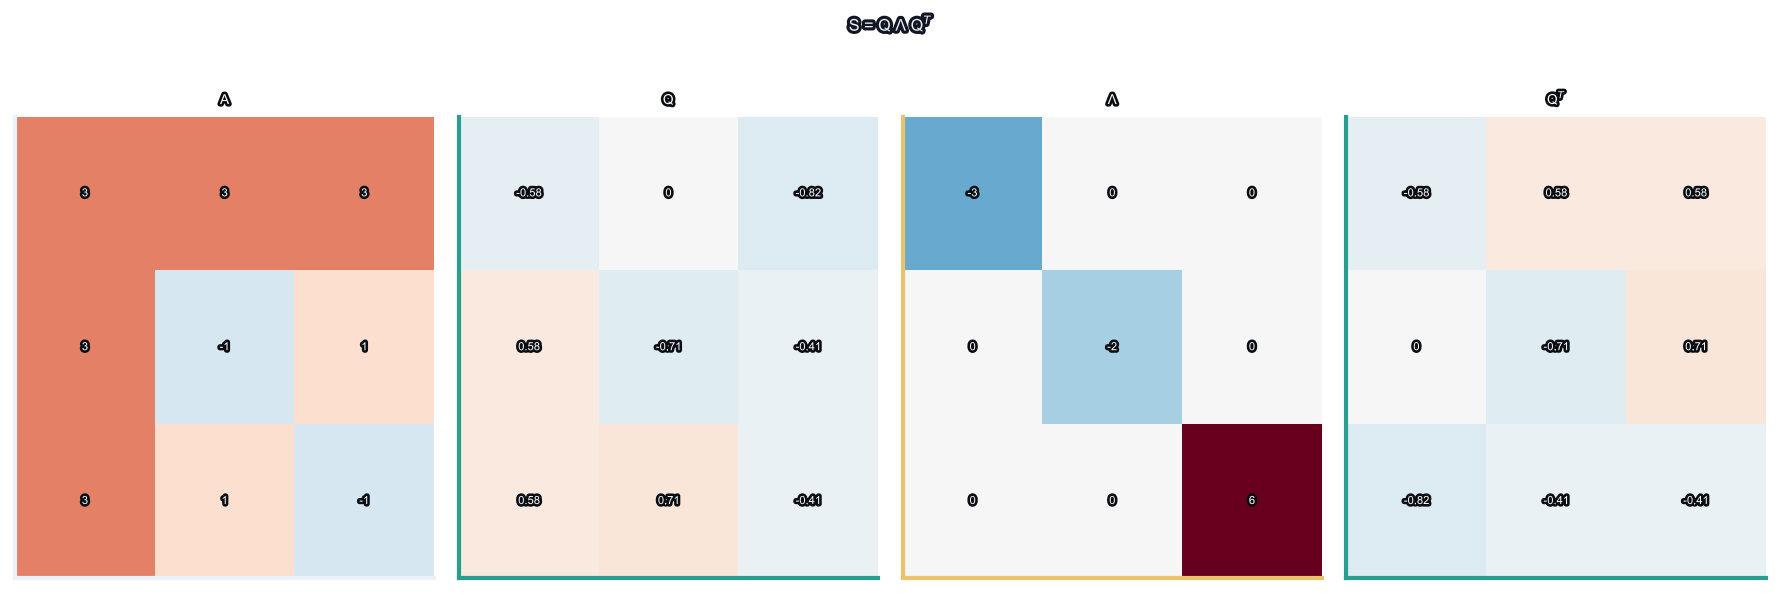

In [14]:
import numpy as np
from aurora.laviz import style, show_factorization
style()
S=np.array([[3.,3,3],[3,-1,1],[3,1,-1]]); w,Q=np.linalg.eigh(S)
show_factorization(S,[Q,np.diag(w),Q.T],['Q','Λ','Qᵀ'],
                   modes=['#2A9D8F','#E9C46A','#2A9D8F'], title='S = Q Λ Qᵀ');

In [15]:
import numpy as np

# 参数实验：改变矩阵参数观察特征值变化
print(f"{'参数 c':>8}  {'λ₁':>10}  {'λ₂':>10}  {'|λ₁/λ₂|':>10}")
for c in [0.5, 1.0, 2.0, 4.0]:
    A = np.array([[3., c],[1., 2.]])
    lam = np.linalg.eigvals(A)
    lam = sorted(lam, key=abs, reverse=True)
    ratio = abs(lam[0]/lam[1]) if abs(lam[1]) > 1e-10 else float('inf')
    print(f'{c:>8.1f}  {lam[0]:>+10.4f}  {lam[1]:>+10.4f}  {ratio:>10.4f}')
print('→ 两特征值相差越大，幂迭代收敛越快（主导方向越突出）。')


    参数 c          λ₁          λ₂     |λ₁/λ₂|
     0.5  +3.3660+0.0000j  +1.6340+0.0000j      2.0600
     1.0  +3.6180+0.0000j  +1.3820+0.0000j      2.6180
     2.0  +4.0000+0.0000j  +1.0000+0.0000j      4.0000
     4.0  +4.5616+0.0000j  +0.4384+0.0000j     10.4039
→ 两特征值相差越大，幂迭代收敛越快（主导方向越突出）。


### 这个比值 `|λ₁/λ₂|` 到底代表什么？

上面代码打印出来的比值，衡量的是"矩阵在最强方向上的拉伸力度，相对于次强方向大多少"。比值越大，说明矩阵的作用越"偏心"——绝大部分的拉伸效果都集中在一个方向上，其他方向几乎没被怎么动。

**为什么这对 PCA 重要？** PCA 要做的事，就是对数据的协方差矩阵做特征分解，然后按特征值从大到小给方向排序：特征值最大的方向，就是数据"散得最开"、信息量最大的方向（第一主成分）。如果最大特征值远远大于第二大的，就说明数据几乎只沿着一个方向变化，把数据压缩到这一个方向上几乎不丢信息——这就是"降维"能生效的原因。反过来，如果所有特征值都差不多大，说明数据在各个方向上都同样重要，压缩会丢掉不少信息。

这也是为什么代码最后一行提到"两特征值相差越大，幂迭代收敛越快"——幂迭代法（一种只用矩阵乘法反复迭代、求最大特征值/特征向量的算法）本质上是不断用 A 去乘一个向量，非主导方向的分量每乘一次就相对衰减一次，比值越大，衰减得越快，也就越快收敛到主导方向。


## 参数实验：稳定边界的两侧

构造特征值分别为 0.9 和 1.1 的矩阵，计算 A^50，观察两个方向的长期行为：
- `0.9^50 ≈ 0.005`：该特征方向已衰减到接近零（稳定）
- `1.1^50 ≈ 117`：该特征方向指数爆炸（不稳定）

只要看特征值的模有没有越过 1.0 这条线，就能预判系统长期行为。Aurora 状态空间模型的稳定性保证，就是把系统矩阵所有特征值的模都约束在单位圆内。

### 为什么判据是"模小于 1"，而不是"数值小于 1"？

上面的例子里，0.9 和 1.1 都是正数，直接比较大小和比较"模"（绝对值）看起来没区别。但如果特征值是**负数**呢？比如系统矩阵的一个特征值是 λ=-0.8——它满足"λ<1"（因为 -0.8 确实比 1 小），如果判据错误地写成"λ<1 就稳定"，会不会出问题？

答案要看 `λⁿ` 到底怎么变化。负数的偶数次幂是正的，奇数次幂是负的——符号会一直交替（这叫"振荡"），但只要 |λ|<1，每振荡一次，幅度都会缩小一点：

- λ=-0.8：`(-0.8)¹=-0.8`，`(-0.8)²=0.64`，`(-0.8)³=-0.512`，... 幅度不断变小，最终趋于 0（收敛，只是路径是"忽正忽负地逼近 0"，不是单调下降）
- 但如果 λ=-1.5（模大于 1）：`(-1.5)¹=-1.5`，`(-1.5)²=2.25`，`(-1.5)³=-3.375`，... 幅度不断变大，同样是振荡，但这次是**振荡着发散**

所以"λ<1"这个条件对负数特征值完全没用（-1.5 也满足 λ<1，但系统会发散）！真正决定收敛还是发散的，只看这个数离 0 有多远——也就是它的**模（绝对值）**：`|λ|<1` 收敛，`|λ|>1` 发散，不管它是正是负、是实数还是复数（复数的"模"是 `√(实部²+虚部²)`，同样的逻辑成立）。


In [16]:
# 亲眼验证：负数特征值的幂次会振荡；只有"模"才能预判收敛还是发散
for lam in [-0.8, -1.5]:
    powers = [lam**n for n in range(1, 6)]
    trend = '收敛' if abs(lam) < 1 else '发散'
    print(f'λ={lam}: λ¹..λ⁵ = {[round(p, 3) for p in powers]}   |λ|={abs(lam)}  → {trend}')


λ=-0.8: λ¹..λ⁵ = [-0.8, 0.64, -0.512, 0.41, -0.328]   |λ|=0.8  → 收敛
λ=-1.5: λ¹..λ⁵ = [-1.5, 2.25, -3.375, 5.062, -7.594]   |λ|=1.5  → 发散


## 本课收束

现在可以用 `np.linalg.eig(A)` 取得特征值数组和特征向量矩阵 `P`，并用 `char_poly(A, lam)` 验证任意 `λ` 是否为真正的特征值。这对应 Aurora 状态空间模型的稳定性检验：对系统矩阵做特征分解，如果所有 `|λ| < 1`，递归滤波器就收敛。下一节（**L18**）补全可逆性判据，使 `A = PΛP⁻¹` 可以精确还原。

---
⬇️ **通关检验**：收束小结已读；请完成下方白板挑战后再勾选自评。


## ✏️ 白板挑战：特征分解手算（目标 10 分钟）

盖上屏幕，纸上作答：

**问 1**：A = [[4, 1], [2, 3]]，手算特征方程 `det(A - λI) = 0`，求两个特征值。

**问 2**：验证：对问 1 的较大特征值 λ₁，`char_poly(A, λ₁)` 应等于多少？

> 💡 这道题看起来像是把定义又抄了一遍——"真特征值代入 char_poly 当然是 0"。但这里的重点不是重复推导，而是**亲手用你自己写的 char_poly 代码，代入一个具体数字算一遍**——这是程序员和科学家常用的"自检"习惯：写完一个函数后，代入一个你已经知道答案的输入，确认代码真的算对了，而不是想当然地相信逻辑推导没问题。如果 char_poly 里有 bug（比如符号写反、少乘了一个负号），这道题就是第一时间能抓出来的地方。

**问 3**：若 A = P diag(2, 5) P⁻¹，A³ = P diag(?, ?) P⁻¹？（不用知道 P 是什么）

**问 4**：一个线性系统的系统矩阵特征值为 [0.9, −0.8]，这个系统稳定吗？  
（判据：所有 |λᵢ| < 1 则稳定——注意 −0.8 是负数，别只看数值大小，要看模）

推导完成后运行下面格对答案。

In [17]:
# ✏️ 对答案格
import numpy as np

A = np.array([[4., 1.], [2., 3.]])

# 问1：特征值
vals_ref = np.sort(np.linalg.eigvals(A))
assert np.allclose(np.sort(vals_ref), [2., 5.], atol=1e-10)
print(f"Q1 ✅  A=[[4,1],[2,3]] 特征值 = {np.sort(vals_ref)}  (手算: λ²-7λ+10=0 → 5,2)")

# 问2：char_poly(A, λ₁) ≈ 0
lam1 = 5.0
try:
    cp = char_poly(A, lam1)
    assert abs(cp) < 1e-8, f"char_poly(A, 5) 应≈0，得到 {cp}"
    print(f"Q2 ✅  char_poly(A, 5) = {cp:.2e}  （λ=5 是真正的特征值）")
except (NotImplementedError, TypeError):
    print("⬜ Q2：请先实现 char_poly()，再运行对答案格")

# 问3：A³ = P diag(2³,5³) P⁻¹
lam3_expected = [2**3, 5**3]  # = [8, 125]
vals3, vecs3 = np.linalg.eig(A)
D3 = np.diag(vals3**3)
A3_diag = vecs3 @ D3 @ np.linalg.inv(vecs3)
A3_ref  = np.linalg.matrix_power(A.astype(int), 3).astype(float)
assert np.allclose(A3_diag, A3_ref, atol=1e-8)
print(f"Q3 ✅  A³ = P·diag({lam3_expected[0]},{lam3_expected[1]})·P⁻¹  (=diag(2³,5³))")

# 问4：稳定性（所有|λ|<1）
eigs_sys = [0.9, -0.8]
stable = all(abs(e) < 1 for e in eigs_sys)
assert stable
print(f"Q4 ✅  特征值={eigs_sys}，|0.9|<1 且 |-0.8|<1 → 系统稳定（Aⁿ→0）")
print("\n🎉 特征分解白板挑战通过！换坐标系让乘法变简单的思想已内化。")

Q1 ✅  A=[[4,1],[2,3]] 特征值 = [2.+0.j 5.+0.j]  (手算: λ²-7λ+10=0 → 5,2)
⬜ Q2：请先实现 char_poly()，再运行对答案格
Q3 ✅  A³ = P·diag(8,125)·P⁻¹  (=diag(2³,5³))
Q4 ✅  特征值=[0.9, -0.8]，|0.9|<1 且 |-0.8|<1 → 系统稳定（Aⁿ→0）

🎉 特征分解白板挑战通过！换坐标系让乘法变简单的思想已内化。


In [ ]:
# ✏️ 本课自评
l17_review = {
    "char_poly_implemented":       None,  # char_poly 实现并通过断言？True/False
    "eigendecomp_A_eq_PDP_inv":   None,  # 理解 A=PDP⁻¹ 的含义？True/False
    "matrix_power_via_diag":      None,  # 知道 Aⁿ=PDⁿP⁻¹？True/False
    "stability_criterion":         None,  # 理解|λ|<1→稳定？True/False
    "whiteboard_passed":           None,  # 白板挑战纸上推导完成？True/False
}

unfilled = [k for k, v in l17_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l17_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L17 全部通关！进入 L18：可逆性与秩')

---

→ **下一课**　[L18 · 可逆性与秩](L18_invertibility.ipynb)

> 下节课将学习 **可逆性与秩**：秩 = 信息量，零空间 = 被压缩的方向，奇异矩阵诊断。